# Repurchase Driver Validation

SQL에서 탐색한 재구매 후보 요인을 Python으로 검증한다.

**Validation scope**
- first-order payment
- first-order category
- cohort effect
- customer experience

> SQL exploratory analysis → statistical validation → business targeting

## 1. Data Connection

PostgreSQL의 분석 마트를 불러와 Python validation 환경을 구성한다.

In [2]:
# - .env의 postgresql 접속 정보 불러오기
# - 실제 db 연결이 가능한지 select 1로 확인

import os
import pandas as pd

from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL as url


# 현재 실행 위치를 기준으로 프로젝트 루트 경로 설정
current_dir = os.getcwd()

if os.path.basename(current_dir).lower() == 'notebooks':
	project_root = os.path.dirname(current_dir)
else:
	project_root = current_dir

load_dotenv(
	os.path.join(project_root, '.env'),
	override=True
)


# 비밀번호에 특수문자가 있어도 안전하게 접속 url 생성
db_url = url.create(
	drivername='postgresql+psycopg2',
	username=os.getenv('db_user'),
	password=os.getenv('db_password'),
	host=os.getenv('db_host'),
	port=int(os.getenv('db_port')),
	database=os.getenv('db_name')
)

engine = create_engine(db_url)


# db 연결 확인
with engine.connect() as conn:
	result = conn.execute(text('select 1'))
	print(result.scalar())

1


In [3]:
# - 분석에서 사용할 두 mart의 schema 위치 확인

query = """
select
	table_schema,
	table_name
from information_schema.views
where table_name in (
	'customer_behavior_mart',
	'order_level_mart'
)
order by table_name;
"""

mart_location = pd.read_sql(query, engine)

mart_location

,table_schema,table_name
0,public,customer_behavior_mart
1,public,order_level_mart


In [4]:
# - 현재 연결된 database를 확인

query = """
select
	current_database() as database_name,
	n.nspname as table_schema,
	c.relname as table_name,
	case
		when c.relkind = 'r' then 'table'
		when c.relkind = 'v' then 'view'
		when c.relkind = 'm' then 'materialized_view'
		else c.relkind::text
	end as object_type
from pg_class c
	inner join pg_namespace n
		on c.relnamespace = n.oid
where c.relname in (
	'customer_behavior_mart',
	'order_level_mart'
)
order by c.relname;
"""

mart_location = pd.read_sql(query, engine)

mart_location

,database_name,table_schema,table_name,object_type
0,olist,public,customer_behavior_mart,view
1,olist,public,order_level_mart,view


In [5]:
# - 두 mart의 실제 컬럼명을 확인

query = """
select
	table_name,
	ordinal_position,
	column_name,
	data_type
from information_schema.columns
where table_schema = 'public'
	and table_name in (
		'customer_behavior_mart',
		'order_level_mart'
	)
order by
	table_name,
	ordinal_position;
"""

mart_columns = pd.read_sql(query, engine)

mart_columns

,table_name,ordinal_position,column_name,data_type
0,customer_behavior_mart,1,customer_unique_id,character varying
1,customer_behavior_mart,2,first_order_id,text
2,customer_behavior_mart,3,first_order_timestamp,text
3,customer_behavior_mart,4,second_order_timestamp,text
4,customer_behavior_mart,5,last_order_timestamp,text
5,customer_behavior_mart,6,order_count,bigint
6,customer_behavior_mart,7,total_payment,real
7,customer_behavior_mart,8,average_order_value,double precision
8,customer_behavior_mart,9,first_order_payment_total,real
9,customer_behavior_mart,10,days_to_second_order,integer


## 2. Base Data Check

고객 단위 분석 마트의 구조와 데이터 규모를 확인한다.

- `customer_behavior_mart`: 고객 행동 및 90일 재구매 지표
- `order_level_mart`: 주문·배송 경험 정보
- validation unit: **1 customer = 1 row**

In [6]:
# - retention validation에 사용할 고객 단위 핵심 컬럼 불러오기
# - 고객 수와 데이터 형태가 sql mart와 일치하는지 확인

query = """
select
	customer_unique_id,
	first_order_id,
	first_order_payment_total,
	eligible_90d,
	repurchase_90d,
	first_order_review_score,
	first_order_delayed_flag,
	cohort_month
from customer_behavior_mart;
"""

retention_base = pd.read_sql(query, engine)

print(retention_base.shape)
retention_base.head()

(93358, 8)


,customer_unique_id,first_order_id,first_order_payment_total,eligible_90d,repurchase_90d,first_order_review_score,first_order_delayed_flag,cohort_month
0,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,86.22,1,0.0,3.0,0.0,2017-03-01
1,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,43.62,1,0.0,4.0,0.0,2017-10-01
2,00050ab1314c0e55a6ca13cf7181fecf,d0028facea13f508e880202d7097a5a1,35.38,1,0.0,4.0,0.0,2018-04-01
3,00053a61a98854899e70ed204dd4bafe,44e608f2db00c74a1fe329de44416a4e,419.18,1,0.0,1.0,0.0,2018-02-01
4,0005e1862207bf6ccc02e4228effd9a0,ae76bef74b97bcb0b3e355e60d9a6f9c,150.12,1,0.0,4.0,0.0,2017-03-01


## 3. Retention Validation Dataset

90일 재구매 분석에 필요한 최소 변수를 구성한다.

**Features**
- first-order payment
- first-order category
- cohort month

**Outcome**
- `repurchase_90d`

90일 전체를 관찰할 수 있는 고객만 retention validation에 사용한다.

In [7]:
# 첫 주문 카테고리 결합
query = """
with first_order_category_base as (
	select
		c.customer_unique_id,
		c.first_order_id,
		i.order_item_id,
		nullif(trim(cat.product_category_name_english), '') as product_category_name_english
	from customer_behavior_mart c
		left join items i
			on c.first_order_id = i.order_id
		left join products p
			on i.product_id = p.product_id
		left join category cat
			on p.product_category_name = cat.product_category_name
),

first_order_category_summary as (
	select
		customer_unique_id,
		first_order_id,
		count(distinct product_category_name_english) as category_cnt,
		count(*) filter (
			where order_item_id is not null
				and product_category_name_english is null
		) as null_category_item_cnt,
		max(product_category_name_english) as single_category_name
	from first_order_category_base
	group by
		customer_unique_id,
		first_order_id
),

category_group_base as (
	select
		customer_unique_id,
		case
			when null_category_item_cnt > 0 then 'unknown_category'
			when category_cnt = 1 then single_category_name
			when category_cnt >= 2 then 'multi_category'
			else 'unknown_category'
		end as first_order_category
	from first_order_category_summary
)

select
	c.customer_unique_id,
	c.first_order_payment_total,
	c.eligible_90d,
	c.repurchase_90d,
	c.cohort_month,
	g.first_order_category
from customer_behavior_mart c
	left join category_group_base g
		on c.customer_unique_id = g.customer_unique_id;
"""

validation_base = pd.read_sql(query, engine)


# 데이터 구조 확인
print('전체 고객:', len(validation_base))
print('고객 중복:', validation_base['customer_unique_id'].duplicated().sum())
print('90일 관찰 가능:', (validation_base['eligible_90d'] == 1).sum())

validation_base.head()

전체 고객: 93358
고객 중복: 0
90일 관찰 가능: 75387


,customer_unique_id,first_order_payment_total,eligible_90d,repurchase_90d,cohort_month,first_order_category
0,0000f46a3911fa3c0805444483337064,86.22,1,0.0,2017-03-01,stationery
1,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,0.0,2017-10-01,telephony
2,00050ab1314c0e55a6ca13cf7181fecf,35.38,1,0.0,2018-04-01,telephony
3,00053a61a98854899e70ed204dd4bafe,419.18,1,0.0,2018-02-01,sports_leisure
4,0005e1862207bf6ccc02e4228effd9a0,150.12,1,0.0,2017-03-01,fashion_bags_accessories


In [8]:
# 90일 관찰 가능 고객만 추출
retention_base = validation_base[validation_base['eligible_90d'] == 1].copy()

print(retention_base.shape)

(75387, 6)


### 3.1 Model Features

90일 관찰 가능 고객을 기준으로 첫 주문금액, 카테고리, cohort를 모델 변수로 구성한다.

In [9]:
# 첫 주문금액 q1~q4 구간 생성
q1 = retention_base['first_order_payment_total'].quantile(0.25)
q2 = retention_base['first_order_payment_total'].quantile(0.50)
q3 = retention_base['first_order_payment_total'].quantile(0.75)

def get_payment_group(x):
	if pd.isna(x): return 'unknown'
	if x <= q1: return 'q1'
	if x <= q2: return 'q2'
	if x <= q3: return 'q3'
	return 'q4'

retention_base['payment_group'] = retention_base['first_order_payment_total'].apply(get_payment_group)

# 모델에 사용할 데이터만 정리
model_base = retention_base[retention_base['payment_group'] != 'unknown'].copy()

print(model_base['payment_group'].value_counts().sort_index())

payment_group
q1    18848
q2    18847
q3    18846
q4    18845
Name: count, dtype: int64


## 4. Retention Driver Validation

첫 주문금액과 카테고리를 함께 고려했을 때도 90일 재구매율 차이가 유지되는지 확인한다.

- outcome: `repurchase_90d`
- features: payment group, first-order category, cohort month
- rare category는 표본 안정성을 위해 `other_category`로 통합

In [10]:
# 주요 카테고리 유지 + multi / unknown 별도 분리
category_count = model_base['first_order_category'].value_counts()

special_category = ['multi_category', 'unknown_category']
major_category = category_count[(category_count >= 1000) & (~category_count.index.isin(special_category))].index
keep_category = major_category.union(special_category)

model_base['category_model'] = model_base['first_order_category'].where(model_base['first_order_category'].isin(keep_category), 'other_category')

print(model_base['category_model'].value_counts())
print()
print('other로 통합된 카테고리 수:', (~category_count.index.isin(keep_category)).sum())

category_model
other_category              8863
bed_bath_table              7035
health_beauty               6161
sports_leisure              6022
computers_accessories       5198
furniture_decor             4916
housewares                  4060
watches_gifts               4016
telephony                   3356
toys                        3198
cool_stuff                  3116
garden_tools                2904
auto                        2785
perfumery                   2465
baby                        2070
electronics                 2037
stationery                  1730
fashion_bags_accessories    1426
unknown_category            1264
pet_shop                    1182
office_furniture            1075
multi_category               507
Name: count, dtype: int64

other로 통합된 카테고리 수: 52


### 4.1 Logistic Regression

첫 주문금액과 카테고리, 구매 시점을 함께 고려해도 첫 주문금액별 재구매 차이가 유지되는지 확인한다.

- outcome: `repurchase_90d`
- main feature: `payment_group`
- controls: `category_model`, `cohort_month`
- reference payment group: `q1`

In [15]:
# cohort를 분기 단위로 단순화
import statsmodels.formula.api as smf

model_base['payment_group'] = pd.Categorical(model_base['payment_group'], categories=['q1', 'q2', 'q3', 'q4'])
model_base['cohort_quarter'] = pd.to_datetime(model_base['cohort_month']).dt.to_period('Q').astype(str)

reg_base = model_base[['repurchase_90d', 'payment_group', 'category_model', 'cohort_quarter']].dropna().copy()

retention_model = smf.logit('repurchase_90d ~ payment_group + category_model + cohort_quarter', data=reg_base).fit(maxiter=200, disp=False)

print('수렴 여부:', retention_model.mle_retvals['converged'])
print('분석 고객:', len(reg_base))
print('재구매 고객:', int(reg_base['repurchase_90d'].sum()))

수렴 여부: True
분석 고객: 75386
재구매 고객: 1716


In [17]:
# 전체 회귀 결과 확인
retention_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         repurchase_90d   No. Observations:                75386
Model:                          Logit   Df Residuals:                    75355
Method:                           MLE   Df Model:                           30
Date:                Wed, 02 Sep 2026   Pseudo R-squ.:                 0.01877
Time:                        00:38:07   Log-Likelihood:                -8033.6
converged:                       True   LL-Null:                       -8187.3
Covariance Type:            nonrobust   LLR p-value:                 9.300e-48
==============================================================================================================
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -4.3799      0.527     -8.305      0.000      -5.414      -3.346
payment_group[T.q2]                           -0.1220      0.069     -1.779      0.075      -0.256       0.012
payment_group[T.q3]                           -0.2038      0.071     -2.867      0.004      -0.343      -0.064
payment_group[T.q4]                           -0.2127      0.072     -2.943      0.003      -0.354      -0.071
category_model[T.baby]                         0.0083      0.226      0.037      0.971      -0.435       0.452
category_model[T.bed_bath_table]               0.8616      0.161      5.343      0.000       0.546       1.178
category_model[T.computers_accessories]        0.2437      0.177      1.379      0.168      -0.103       0.590
category_model[T.cool_stuff]                  -0.6033      0.239     -2.524      0.012      -1.072      -0.135
category_model[T.electronics]                 -0.5200      0.262     -1.982      0.047      -1.034      -0.006
category_model[T.fashion_bags_accessories]     0.9454      0.197      4.799      0.000       0.559       1.331
category_model[T.furniture_decor]              0.7222      0.169      4.282      0.000       0.392       1.053
category_model[T.garden_tools]                -0.0076      0.209     -0.036      0.971      -0.417       0.401
category_model[T.health_beauty]                0.3040      0.172      1.769      0.077      -0.033       0.641
category_model[T.housewares]                  -0.0133      0.192     -0.069      0.945      -0.390       0.364
category_model[T.multi_category]               1.2608      0.249      5.071      0.000       0.773       1.748
category_model[T.office_furniture]            -0.0690      0.294     -0.235      0.814      -0.645       0.507
category_model[T.other_category]               0.3626      0.164      2.207      0.027       0.041       0.685
category_model[T.perfumery]                    0.0565      0.213      0.265      0.791      -0.361       0.474
category_model[T.pet_shop]                     0.2057      0.255      0.808      0.419      -0.293       0.705
category_model[T.sports_leisure]               0.5338      0.168      3.181      0.001       0.205       0.863
category_model[T.stationery]                  -0.2405      0.258     -0.934      0.350      -0.745       0.264
category_model[T.telephony]                   -0.2032      0.207     -0.983      0.326      -0.609       0.202
category_model[T.toys]                        -0.0081      0.203     -0.040      0.968      -0.406       0.390
category_model[T.unknown_category]             0.0434      0.258      0.168      0.866      -0.462       0.549
category_model[T.watches_gifts]                0.0067      0.195      0.034      0.973      -0.376       0.390
cohort_quarter[T.2017Q1]                       0.4671      0.513      0.910      0.363      -0.539       1.473
cohort_quarter[T.2017Q

In [18]:
# 변수 단위 유의성 확인
term_test = retention_model.wald_test_terms()

term_test

<class 'statsmodels.stats.contrast.WaldTestResults'>
                      chi2        P>chi2  df constraint
Intercept        68.970096  9.996780e-17              1
payment_group    11.371580  9.877285e-03              3
category_model  251.471224  2.079956e-41             21
cohort_quarter   39.839244  4.898770e-07              6

### 4.2 Payment Effect

카테고리와 cohort를 함께 고려한 상태에서 q1 대비 q2~q4의 90일 재구매 odds를 비교한다.

In [16]:
# payment 결과만 추출
import numpy as np

result = pd.DataFrame({'odds_ratio': np.exp(retention_model.params), 'p_value': retention_model.pvalues, 'ci_lower': np.exp(retention_model.conf_int()[0]), 'ci_upper': np.exp(retention_model.conf_int()[1])})

payment_result = result[result.index.str.startswith('payment_group')].round(4)

payment_result

,odds_ratio,p_value,ci_lower,ci_upper
payment_group[T.q2],0.8851,0.0752,0.7738,1.0125
payment_group[T.q3],0.8156,0.0041,0.7096,0.9376
payment_group[T.q4],0.8084,0.0032,0.7017,0.9314


### Key Findings

- 분석 대상 75,386명, 90일 내 재구매 고객 1,716명
- payment group, category, cohort 모두 재구매와 유의한 관계를 보였다.
- q3는 q1 대비 재구매 odds가 약 18.4% 낮았다. (OR 0.8156, p=0.0041)
- q4는 q1 대비 재구매 odds가 약 19.2% 낮았다. (OR 0.8084, p=0.0032)
- q2는 q1 대비 차이가 유의하지 않았다. (p=0.0752)
- 카테고리와 구매 시점을 함께 고려한 뒤에도 q3·q4의 낮은 재구매 odds가 유지됐다.
- 첫 주문금액은 인과적 driver라기보다 retention targeting signal로 활용하는 것이 적절하다.

## 5. CX Validation

배송 지연이 고객 리뷰 경험과 어떤 관계를 보이는지 확인한다.

- outcome: `low_review_flag` (review score < 3)
- main feature: `4일 이상 배송 지연`
- controls: payment group, category, cohort
- comparison: 1~3일 지연 vs 4일 이상 지연

In [19]:
# cx 분석 데이터 구성
query = """
select
	c.customer_unique_id,
	c.first_order_payment_total,
	c.cohort_month,
	o.delivery_delay_days,
	o.review_score
from customer_behavior_mart c
	inner join order_level_mart o
		on c.first_order_id = o.order_id
where o.delayed_flag = 1
	and o.delivery_delay_days is not null;
"""

cx_base = pd.read_sql(query, engine)

# 기존 category 정보 결합
cx_base = cx_base.merge(validation_base[['customer_unique_id', 'first_order_category']], on='customer_unique_id', how='left')

# 모델 변수 구성
cx_base['payment_group'] = pd.cut(cx_base['first_order_payment_total'], bins=[float('-inf'), q1, q2, q3, float('inf')], labels=['q1', 'q2', 'q3', 'q4'])
cx_base['category_model'] = cx_base['first_order_category'].where(cx_base['first_order_category'].isin(keep_category), 'other_category')
cx_base['cohort_quarter'] = pd.to_datetime(cx_base['cohort_month']).dt.to_period('Q').astype(str)
cx_base['delay_group'] = np.where(cx_base['delivery_delay_days'] <= 3, '1-3d', '4d plus')

cx_base['low_review_flag'] = (cx_base['review_score'] < 3).astype('Int64')
cx_base.loc[cx_base['review_score'].isna(), 'low_review_flag'] = pd.NA

# 그룹별 cx 확인
cx_summary = cx_base.groupby('delay_group').agg(customer_cnt=('customer_unique_id', 'count'), avg_review_score=('review_score', 'mean'), low_review_rate=('low_review_flag', 'mean')).reset_index()

cx_summary['avg_review_score'] = cx_summary['avg_review_score'].round(2)
cx_summary['low_review_rate'] = (cx_summary['low_review_rate'] * 100).round(2)

cx_summary

,delay_group,customer_cnt,avg_review_score,low_review_rate
0,1-3d,1821,3.29,32.08
1,4d plus,4534,1.85,75.02


### 5.1 Logistic Regression

첫 주문금액, 카테고리, 구매 시점을 함께 고려한 뒤에도 4일 이상 배송 지연과 저리뷰의 관계가 유지되는지 확인한다.

- outcome: `low_review_flag`
- main feature: `delay_group`
- controls: payment group, category, cohort
- reference: 1~3일 지연

In [20]:
# cx 로지스틱 회귀
cx_model_base = cx_base[['low_review_flag', 'delay_group', 'payment_group', 'category_model', 'cohort_quarter']].dropna().copy()

cx_model_base['delay_group'] = pd.Categorical(cx_model_base['delay_group'], categories=['1-3d', '4d plus'])

cx_model = smf.logit('low_review_flag ~ delay_group + payment_group + category_model + cohort_quarter', data=cx_model_base).fit(maxiter=200, disp=False)

print('수렴 여부:', cx_model.mle_retvals['converged'])
print('분석 고객:', len(cx_model_base))
print('저리뷰 고객:', int(cx_model_base['low_review_flag'].sum()))

수렴 여부: True
분석 고객: 6208
저리뷰 고객: 3882


In [22]:
# 전체 회귀 결과 확인
cx_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        low_review_flag   No. Observations:                 6208
Model:                          Logit   Df Residuals:                     6175
Method:                           MLE   Df Model:                           32
Date:                Wed, 02 Sep 2026   Pseudo R-squ.:                  0.1350
Time:                        01:36:19   Log-Likelihood:                -3551.7
converged:                       True   LL-Null:                       -4106.0
Covariance Type:            nonrobust   LLR p-value:                2.116e-212
==============================================================================================================
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -0.8384      1.577     -0.532      0.595      -3.930       2.253
delay_group[T.4d plus]                         1.8068      0.062     29.016      0.000       1.685       1.929
payment_group[T.q2]                            0.0393      0.089      0.442      0.658      -0.135       0.213
payment_group[T.q3]                           -0.0108      0.089     -0.121      0.903      -0.185       0.163
payment_group[T.q4]                            0.1246      0.088      1.411      0.158      -0.048       0.298
category_model[T.baby]                         0.1386      0.211      0.656      0.512      -0.276       0.553
category_model[T.bed_bath_table]               0.0507      0.167      0.304      0.761      -0.277       0.378
category_model[T.computers_accessories]       -0.0854      0.181     -0.473      0.636      -0.440       0.269
category_model[T.cool_stuff]                   0.0488      0.214      0.228      0.819      -0.370       0.467
category_model[T.electronics]                 -0.1316      0.220     -0.599      0.549      -0.562       0.299
category_model[T.fashion_bags_accessories]    -0.0200      0.272     -0.074      0.941      -0.552       0.512
category_model[T.furniture_decor]             -0.0419      0.178     -0.236      0.814      -0.390       0.306
category_model[T.garden_tools]                 0.0155      0.209      0.074      0.941      -0.395       0.426
category_model[T.health_beauty]               -0.0729      0.167     -0.438      0.662      -0.399       0.254
category_model[T.housewares]                   0.0453      0.193      0.234      0.815      -0.334       0.424
category_model[T.multi_category]              -0.2905      0.695     -0.418      0.676      -1.653       1.072
category_model[T.office_furniture]             0.0804      0.273      0.294      0.769      -0.455       0.616
category_model[T.other_category]               0.0005      0.164      0.003      0.997      -0.320       0.321
category_model[T.perfumery]                    0.0731      0.215      0.340      0.734      -0.349       0.495
category_model[T.pet_shop]                    -0.0861      0.288     -0.299      0.765      -0.650       0.478
category_model[T.sports_leisure]               0.0635      0.175      0.362      0.717      -0.280       0.407
category_model[T.stationery]                  -0.0388      0.236     -0.165      0.869      -0.501       0.424
category_model[T.telephony]                   -0.2692      0.195     -1.379      0.168      -0.652       0.113
category_model[T.toys]                         0.2247      0.211      1.066      0.286      -0.188       0.638
category_model[T.unknown_category]             0.3044      0.278      1.094      0.274      -0.241       0.850
category_model[T.watches_gifts]               -0.0241      0.181     -0.133      0.894      -0.379       0.331
cohort_quarter[T.2017Q

In [23]:
# 변수 단위 유의성 확인
cx_term_test = cx_model.wald_test_terms()

cx_term_test

<class 'statsmodels.stats.contrast.WaldTestResults'>
                      chi2         P>chi2  df constraint
Intercept         0.282622   5.949881e-01              1
delay_group     841.912456  4.167017e-185              1
payment_group     3.408015   3.328897e-01              3
category_model   11.580687   9.502526e-01             21
cohort_quarter   93.835951   2.012839e-17              7

In [21]:
# 4일 이상 지연 결과 확인
cx_result = pd.DataFrame({'odds_ratio': np.exp(cx_model.params), 'p_value': cx_model.pvalues, 'ci_lower': np.exp(cx_model.conf_int()[0]), 'ci_upper': np.exp(cx_model.conf_int()[1])})

cx_result.loc[cx_result.index.str.startswith('delay_group')].round(4)

,odds_ratio,p_value,ci_lower,ci_upper
delay_group[T.4d plus],6.0907,0.0,5.3909,6.8813


### 5.2 Delivery Delay Effect

첫 주문금액, 카테고리, cohort를 함께 고려한 상태에서 1~3일 지연 대비 4일 이상 지연 고객의 저리뷰 odds를 비교한다.

In [24]:
# 4일 이상 지연 오즈비 확인
cx_result = pd.DataFrame({
	'odds_ratio': np.exp(cx_model.params),
	'p_value': cx_model.pvalues,
	'ci_lower': np.exp(cx_model.conf_int()[0]),
	'ci_upper': np.exp(cx_model.conf_int()[1])
})

cx_result = cx_result[cx_result.index.str.startswith('delay_group')].round(4)

cx_result

,odds_ratio,p_value,ci_lower,ci_upper
delay_group[T.4d plus],6.0907,0.0,5.3909,6.8813


### 5.3 Delay Severity and Low Review Rate

배송 지연 기간별 저리뷰율을 비교해 CX 악화가 시작되는 구간을 확인한다.

In [25]:
# 배송 지연 기간별 저리뷰율
cx_base['delay_severity'] = pd.cut(cx_base['delivery_delay_days'], bins=[0, 3, 7, 13, float('inf')], labels=['1-3d', '4-7d', '8-13d', '14d plus'])

delay_summary = cx_base.groupby('delay_severity', observed=True)['low_review_flag'].mean().mul(100).reset_index(name='low_review_rate')
delay_summary['low_review_rate'] = delay_summary['low_review_rate'].round(2)

delay_summary

,delay_severity,low_review_rate
0,1-3d,32.08
1,4-7d,68.08
2,8-13d,79.79
3,14d plus,79.0


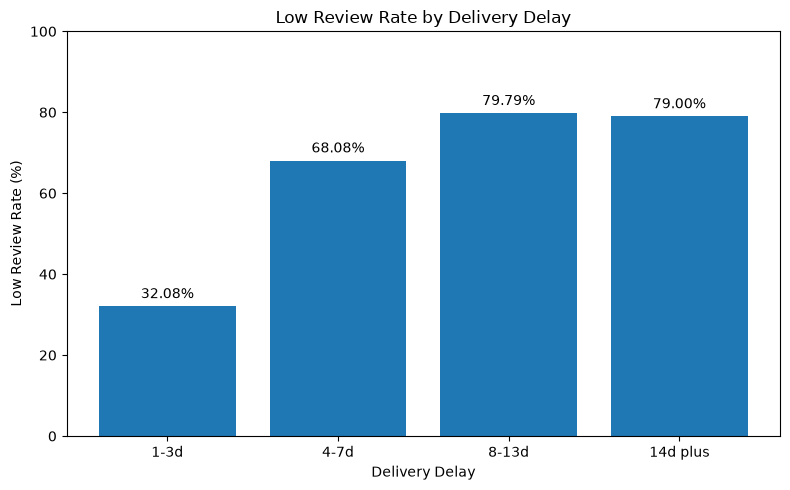

In [26]:
# 저리뷰율 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
bars = plt.bar(delay_summary['delay_severity'].astype(str), delay_summary['low_review_rate'])

plt.title('Low Review Rate by Delivery Delay')
plt.xlabel('Delivery Delay')
plt.ylabel('Low Review Rate (%)')
plt.ylim(0, 100)

for bar, value in zip(bars, delay_summary['low_review_rate']):
	plt.text(bar.get_x() + bar.get_width() / 2, value + 2, f'{value:.2f}%', ha='center')

plt.tight_layout()
plt.show()

### Key Findings

- 배송 지연 고객 6,208명을 대상으로 저리뷰 여부를 검증했다.
- delay group과 cohort는 저리뷰 여부와 유의한 관계를 보였고, payment와 category는 유의하지 않았다.
- 4일 이상 지연 고객의 저리뷰 odds는 1~3일 지연 고객 대비 약 6.1배 높았다. (OR 6.0907, p<0.001)
- 배송 지연 기간별 저리뷰율은 1~3일 32.08%에서 4~7일 68.08%로 급증했고, 8일 이상에서는 약 79~80% 수준을 유지했다.
- payment,category,cohort를 함께 고려한 뒤에도 배송 지연과 저리뷰의 강한 관계가 유지됐다.따라서 4일 이상 배송 지연을 CX 개선 대상 선정 기준으로 활용한다.